<a href="https://colab.research.google.com/github/SakshyamSingB/AI-ML/blob/main/vision_notebook_SakshyamSingBhandari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Part II: Vision Task
## Land Use & Land Cover Classification of Sentinel-2 Satellite Images using CNNs and Transfer Learning


This notebook completes every required item:
- **2.5.1** Data understanding, analysis, visualisation, cleaning
- **2.5.2** Baseline CNN from scratch (3 Conv+Pool + 3 FCN + output)
- **2.5.3** Deeper CNN with Batch Normalisation + Dropout (≥2× layers)
- **2.5.4** Comparative analysis: Baseline vs Deeper, SGD vs Adam, Ablation study
- **Part B** Transfer learning with ResNet50 on 224×224



## 0. Environment & Reproducibility

In [ ]:
import os, random, time, pathlib, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, applications

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_style('whitegrid')

print('TensorFlow :', tf.__version__)
print('GPUs       :', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Acquire the EuroSAT Dataset



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

RESULTS_FILE = "/content/drive/MyDrive/vision_training_results.txt"

Mounted at /content/drive


In [ ]:
RESULTS_FILE = "/content/drive/MyDrive/vision_training_results.txt"

with open(RESULTS_FILE, "w") as f:
    f.write("Vision Training Results\n")
    f.write("=======================\n\n")

In [ ]:
from google.colab import drive
import pathlib
import zipfile



ZIP_PATH = '/content/drive/MyDrive/EuroSAT.zip'
EXTRACT_DIR = '/content/EuroSAT'

!mkdir -p /content/EuroSAT

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

DATA_DIR = pathlib.Path('/content/EuroSAT/EuroSAT')

if not DATA_DIR.exists():
    raise ValueError('DATA_DIR not found at /content/EuroSAT/EuroSAT')

class_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]

if len(class_dirs) == 0:
    raise ValueError('No class folders found in DATA_DIR')

print("DATA_DIR =", DATA_DIR.resolve())
print("Classes:", len(class_dirs))

DATA_DIR = /content/EuroSAT/EuroSAT
Classes: 10


## 2.5.1 — Data Understanding, Analysis, Visualisation, Cleaning

In [ ]:
CLASS_NAMES = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f'{NUM_CLASSES} classes:', CLASS_NAMES)

counts = {c: len(list((DATA_DIR/c).glob('*.jpg'))) for c in CLASS_NAMES}
df_counts = (pd.DataFrame({'class': counts.keys(), 'count': counts.values()})
             .assign(percent=lambda d: (d['count']/d['count'].sum()*100).round(2)))
print('Total images:', df_counts['count'].sum())
df_counts

10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


,class,count,percent
0,AnnualCrop,3000,11.11
1,Forest,3000,11.11
2,HerbaceousVegetation,3000,11.11
3,Highway,2500,9.26
4,Industrial,2500,9.26
5,Pasture,2000,7.41
6,PermanentCrop,2500,9.26
7,Residential,3000,11.11
8,River,2500,9.26
9,SeaLake,3000,11.11


/tmp/ipykernel_1620/2557042908.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_counts['class'], rotation=30, ha='right')


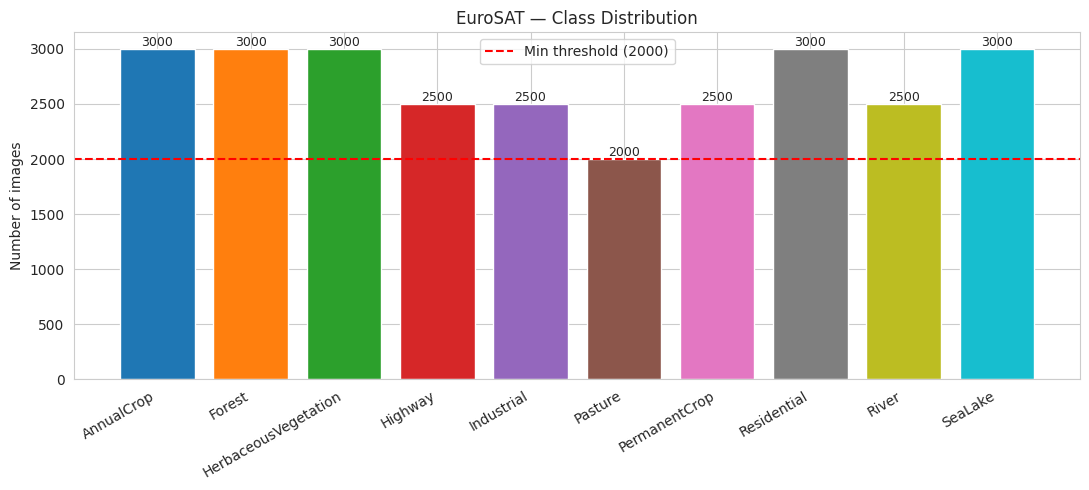

In [ ]:
# Class-distribution bar chart (matches Figure 1 of the proposal)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(df_counts['class'], df_counts['count'], color=sns.color_palette('tab10'))
ax.axhline(2000, ls='--', color='red', label='Min threshold (2000)')
for b, v in zip(bars, df_counts['count']):
    ax.text(b.get_x()+b.get_width()/2, v+30, str(v), ha='center', fontsize=9)
ax.set_xticklabels(df_counts['class'], rotation=30, ha='right')
ax.set_ylabel('Number of images'); ax.set_title('EuroSAT — Class Distribution')
ax.legend(); plt.tight_layout(); plt.show()

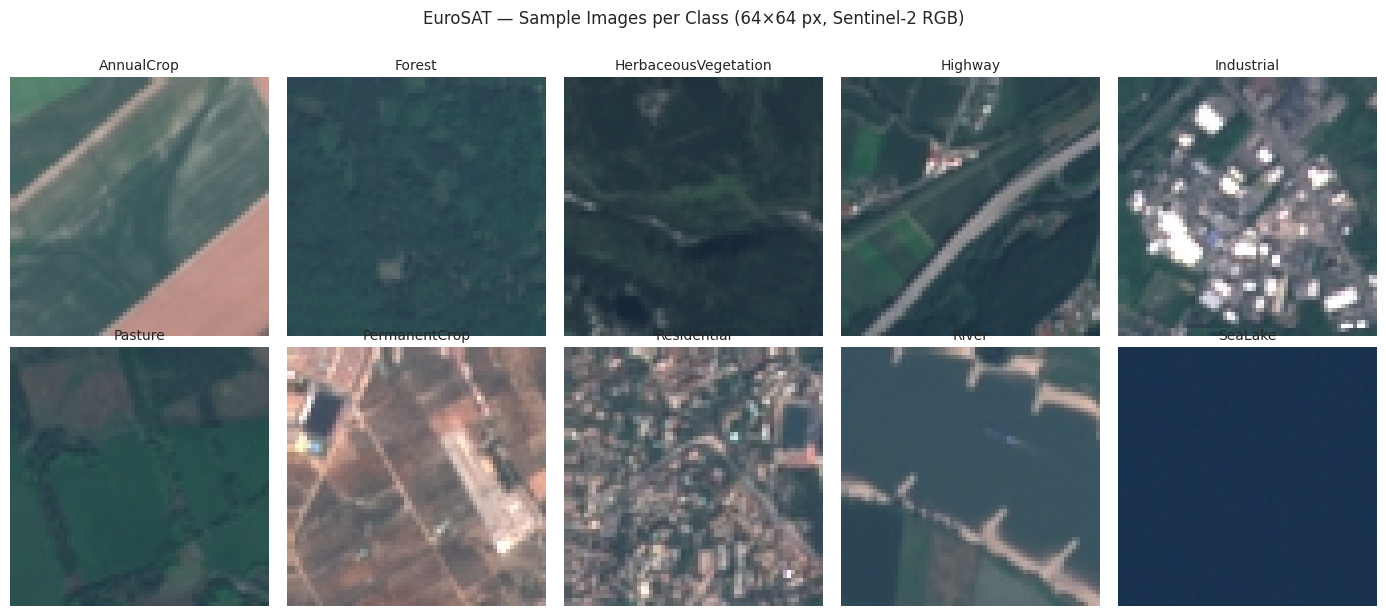

In [ ]:
# Sample image per class (matches Figure 3 of the proposal)
from PIL import Image
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    img_path = next((DATA_DIR/cls).glob('*.jpg'))
    ax.imshow(Image.open(img_path)); ax.set_title(cls, fontsize=10); ax.axis('off')
plt.suptitle('EuroSAT — Sample Images per Class (64×64 px, Sentinel-2 RGB)', y=1.02)
plt.tight_layout(); plt.show()

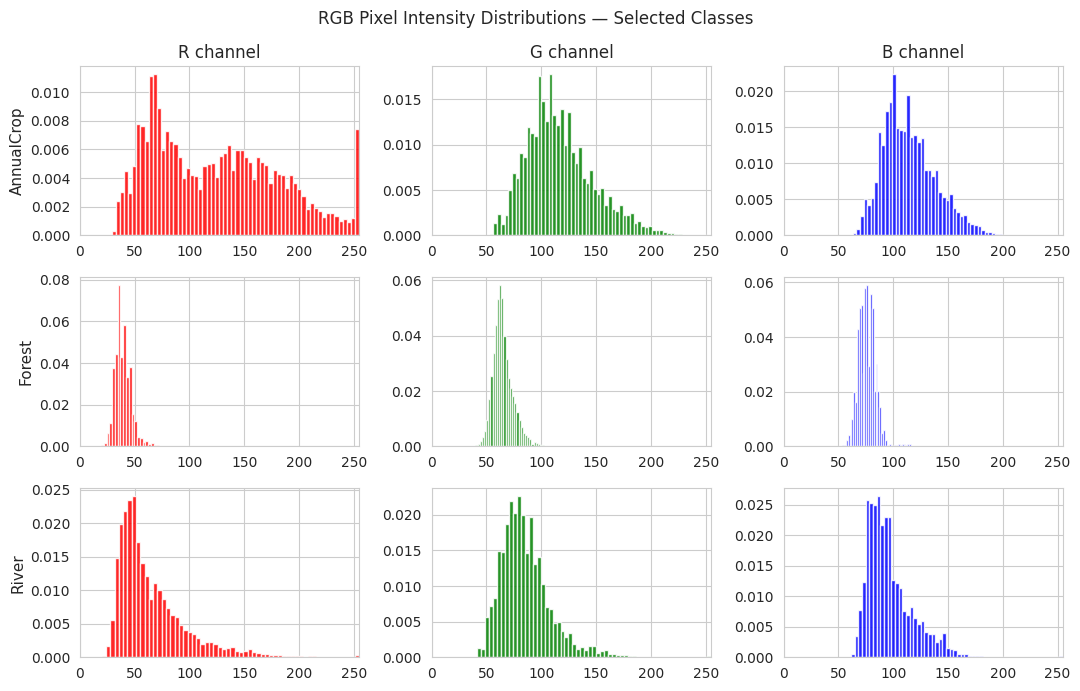

In [ ]:
# RGB pixel-intensity histograms for 3 contrasting classes (Figure 4 of proposal)
def channel_hist(class_name, n_imgs=200, ax_row=None):
    files = list((DATA_DIR/class_name).glob('*.jpg'))[:n_imgs]
    arrs = np.stack([np.array(Image.open(f)) for f in files])
    for ch, color, ax in zip(range(3), ['red','green','blue'], ax_row):
        ax.hist(arrs[..., ch].ravel(), bins=60, color=color, density=True, alpha=0.85)
        ax.set_xlim(0, 255)

fig, axes = plt.subplots(3, 3, figsize=(11, 7))
for row, cls in zip(axes, ['AnnualCrop', 'Forest', 'River']):
    channel_hist(cls, ax_row=row)
    row[0].set_ylabel(cls, fontsize=11)
for ax, t in zip(axes[0], ['R channel','G channel','B channel']): ax.set_title(t)
plt.suptitle('RGB Pixel Intensity Distributions — Selected Classes')
plt.tight_layout(); plt.show()

In [ ]:
from google.colab import drive
import os



RESULTS_FILE = "/content/drive/MyDrive/vision_training_results.txt"

if os.path.exists(RESULTS_FILE):
    print("File found:", RESULTS_FILE)
    print("\n--- File contents ---\n")
    with open(RESULTS_FILE, "r") as f:
        print(f.read())
else:
    print("File not found:", RESULTS_FILE)

File found: /content/drive/MyDrive/vision_training_results.txt

--- File contents ---

Vision Training Results

Baseline CNN
Test Accuracy: 0.8926
Test Precision (weighted): 0.8958
Test Recall (weighted): 0.8926
Test F1 Score (weighted): 0.8924

Deeper CNN
Test Accuracy: 0.9175
Test Precision (weighted): 0.9253
Test Recall (weighted): 0.9175
Test F1 Score (weighted): 0.9182

Optimizer Comparison: SGD vs Adam
SGD Final Validation Accuracy: 0.8333
SGD Training Time: 602.3 seconds
Adam Final Validation Accuracy: 0.8210
Adam Training Time: 697.4 seconds



### Train / Validation / Test split — 70 / 15 / 15



In [ ]:
IMG_SIZE = (64, 64)
BATCH = 64
AUTOTUNE = tf.data.AUTOTUNE

# 70/15/15 split achieved by: take 30% as validation+test, then split that 50/50
full_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, image_size=IMG_SIZE, batch_size=None, seed=SEED, shuffle=True,
    label_mode='int', class_names=CLASS_NAMES)

# materialise once → reproducible split
images, labels = [], []
for x, y in full_ds:
    images.append(x.numpy()); labels.append(y.numpy())
X = np.stack(images); y = np.array(labels)
print('All:', X.shape, y.shape)

from sklearn.model_selection import train_test_split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print('Train:', X_tr.shape, ' Val:', X_val.shape, ' Test:', X_te.shape)

Found 27000 files belonging to 10 classes.
All: (27000, 64, 64, 3) (27000,)
Train: (18900, 64, 64, 3)  Val: (4050, 64, 64, 3)  Test: (4050, 64, 64, 3)


In [ ]:
# Build tf.data pipelines with rescaling + augmentation (training only)
data_aug = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='augmentation')

def to_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype('float32')/255.0, y))
    if training:
        ds = ds.shuffle(2048, seed=SEED).map(lambda x,y: (data_aug(x, training=True), y),
                                              num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = to_ds(X_tr, y_tr, training=True)
val_ds   = to_ds(X_val, y_val)
test_ds  = to_ds(X_te,  y_te)

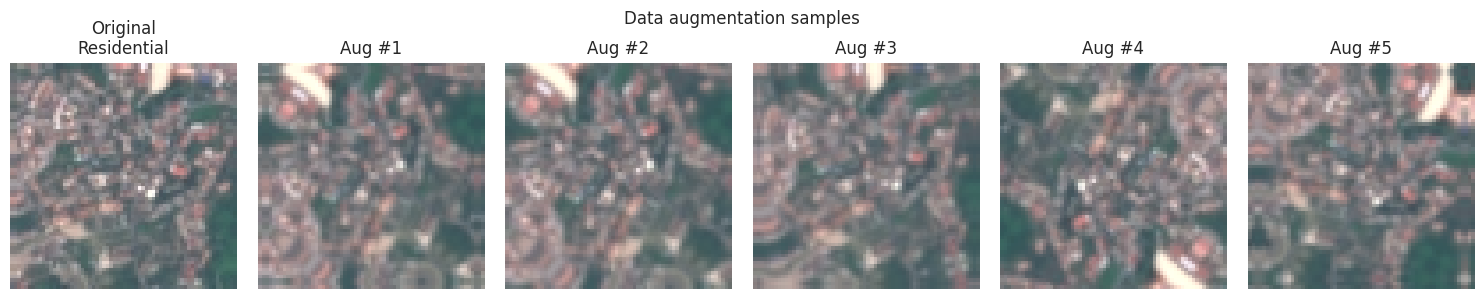

In [ ]:
sample_x, sample_y = X_tr[0], y_tr[0]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

axes[0].imshow(sample_x.astype('uint8'))
axes[0].set_title(f'Original\n{CLASS_NAMES[sample_y]}')
axes[0].axis('off')

for i, ax in enumerate(axes[1:], 1):
    img = tf.convert_to_tensor(sample_x, dtype=tf.float32)

    aug = data_aug(img, training=True).numpy()
    aug = np.clip(aug, 0, 255).astype('uint8')

    ax.imshow(aug)
    ax.set_title(f'Aug #{i}')
    ax.axis('off')

plt.suptitle('Data augmentation samples')
plt.tight_layout()
plt.show()

## 2.5.2 — Baseline CNN (from scratch)

In [ ]:
def build_baseline():
    m = keras.Sequential([
        layers.Input((64, 64, 3)),
        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # FCN head — 3 dense layers + output
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='baseline_cnn')
    return m

baseline = build_baseline()
baseline.compile(optimizer=optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,458 (8.52 MB)

 Trainable params: 2,232,458 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_BASE = 25
es = callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy')

t0 = time.time()
hist_base = baseline.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_BASE, callbacks=[es], verbose=2)
time_base = time.time() - t0
print(f'Baseline training time: {time_base:.1f} s')

Epoch 1/25
296/296 - 47s - 159ms/step - accuracy: 0.4365 - loss: 1.4940 - val_accuracy: 0.5632 - val_loss: 1.2116
Epoch 2/25
296/296 - 38s - 127ms/step - accuracy: 0.6371 - loss: 0.9962 - val_accuracy: 0.6311 - val_loss: 1.0297
Epoch 3/25
296/296 - 48s - 162ms/step - accuracy: 0.7037 - loss: 0.8129 - val_accuracy: 0.7479 - val_loss: 0.6964
Epoch 4/25
296/296 - 70s - 237ms/step - accuracy: 0.7401 - loss: 0.7149 - val_accuracy: 0.7348 - val_loss: 0.7636
Epoch 5/25
296/296 - 40s - 135ms/step - accuracy: 0.7702 - loss: 0.6376 - val_accuracy: 0.7627 - val_loss: 0.6752
Epoch 6/25
296/296 - 37s - 126ms/step - accuracy: 0.7767 - loss: 0.6253 - val_accuracy: 0.7662 - val_loss: 0.6508
Epoch 7/25
296/296 - 41s - 139ms/step - accuracy: 0.7899 - loss: 0.5791 - val_accuracy: 0.8067 - val_loss: 0.5464
Epoch 8/25
296/296 - 40s - 136ms/step - accuracy: 0.7974 - loss: 0.5738 - val_accuracy: 0.7956 - val_loss: 0.5808
Epoch 9/25
296/296 - 41s - 139ms/step - accuracy: 0.8120 - loss: 0.5164 - val_accuracy: 

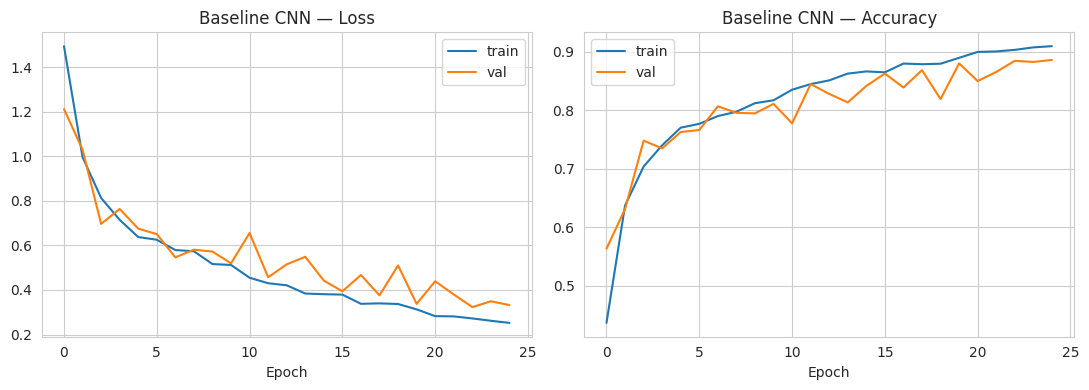

In [ ]:
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h.history['loss'], label='train'); ax[0].plot(h.history['val_loss'], label='val')
    ax[0].set_title(f'{title} — Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()
    ax[1].plot(h.history['accuracy'], label='train'); ax[1].plot(h.history['val_accuracy'], label='val')
    ax[1].set_title(f'{title} — Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(hist_base, 'Baseline CNN')


=== Baseline CNN ===
Test accuracy : 0.8926
Precision (w) : 0.8958
Recall    (w) : 0.8926
F1-score  (w) : 0.8924

Classification report:
                       precision    recall  f1-score   support

          AnnualCrop       0.94      0.88      0.91       450
              Forest       0.98      0.94      0.96       450
HerbaceousVegetation       0.91      0.81      0.86       450
             Highway       0.84      0.82      0.83       375
          Industrial       0.94      0.90      0.92       375
             Pasture       0.84      0.90      0.87       300
       PermanentCrop       0.82      0.76      0.79       375
         Residential       0.82      1.00      0.90       450
               River       0.85      0.93      0.89       375
             SeaLake       0.99      0.96      0.97       450

            accuracy                           0.89      4050
           macro avg       0.89      0.89      0.89      4050
        weighted avg       0.90      0.89      0.89  

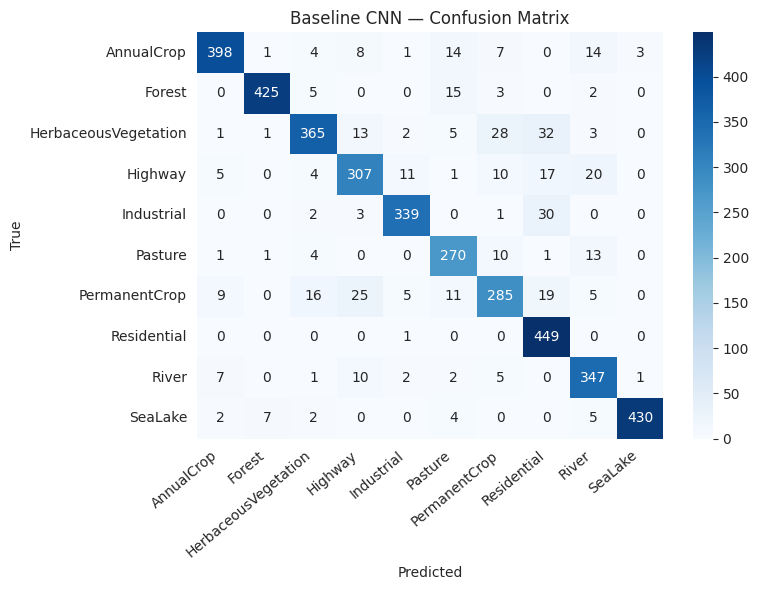

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score)

def evaluate_model(model, name):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    acc = accuracy_score(y_te, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_te, y_pred, average='weighted')
    print(f'\n=== {name} ===')
    print(f'Test accuracy : {acc:.4f}')
    print(f'Precision (w) : {p:.4f}')
    print(f'Recall    (w) : {r:.4f}')
    print(f'F1-score  (w) : {f:.4f}')
    print('\nClassification report:\n', classification_report(y_te, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'{name} — Confusion Matrix')
    plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()
    return {'name': name, 'accuracy': acc, 'precision': p, 'recall': r, 'f1': f}

results = []
results.append(evaluate_model(baseline, 'Baseline CNN'))
with open(RESULTS_FILE, "a") as f:
    f.write("Baseline CNN\n")
    f.write(f"Training Time: {time_base:.2f} seconds\n")
    f.write(f"Final Training Accuracy: {hist_base.history['accuracy'][-1]:.4f}\n")
    f.write(f"Final Validation Accuracy: {hist_base.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"Test Accuracy: {results[-1]['accuracy']:.4f}\n")
    f.write(f"Test Precision: {results[-1]['precision']:.4f}\n")
    f.write(f"Test Recall: {results[-1]['recall']:.4f}\n")
    f.write(f"Test F1 Score: {results[-1]['f1']:.4f}\n\n")

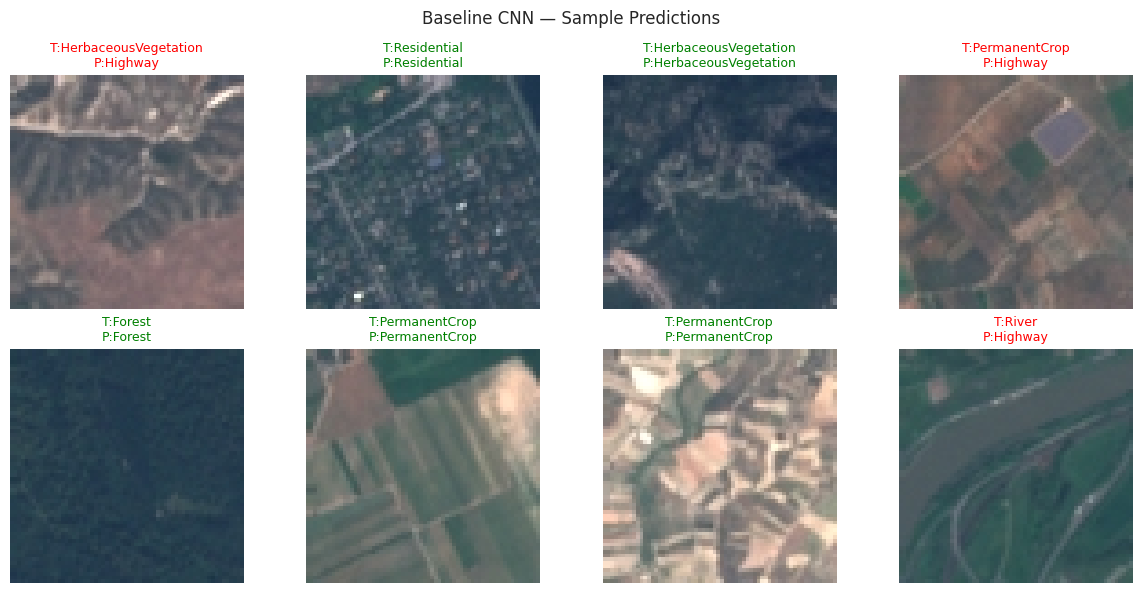

In [ ]:
idx = np.random.RandomState(SEED).choice(len(X_te), 8, replace=False)

preds = np.argmax(baseline.predict(X_te[idx] / 255.0, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, i, p in zip(axes.flat, idx, preds):
    img = X_te[i]

    if img.max() > 1:
        img = img / 255.0

    ax.imshow(img)
    ax.axis('off')

    color = 'green' if p == y_te[i] else 'red'
    ax.set_title(f'T:{CLASS_NAMES[y_te[i]]}\nP:{CLASS_NAMES[p]}', color=color, fontsize=9)

plt.suptitle('Baseline CNN — Sample Predictions')
plt.tight_layout()
plt.show()

## 2.5.3 — Deeper CNN with Batch Normalisation + Dropout

In [ ]:
def build_deeper():
    m = keras.Sequential([
        layers.Input((64, 64, 3)),
        # Block 1 (×2 conv)
        layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(), layers.Dropout(0.20),
        # Block 2 (×2 conv)
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(), layers.Dropout(0.25),
        # Block 3 (×2 conv)
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(), layers.Dropout(0.30),
        # Block 4 (×2 conv) — extra depth
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.GlobalAveragePooling2D(), layers.Dropout(0.40),
        # FCN head
        layers.Dense(256, activation='relu'), layers.Dropout(0.40),
        layers.Dense(128, activation='relu'), layers.Dropout(0.30),
        layers.Dense(64,  activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='deeper_cnn')
    return m

deeper = build_deeper()
deeper.compile(optimizer=optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
deeper.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 128)    │             

 Total params: 1,283,690 (4.90 MB)

 Trainable params: 1,281,770 (4.89 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
EPOCHS_DEEP = 35
es2 = callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy')
rlr = callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', min_lr=1e-6)

t0 = time.time()
hist_deep = deeper.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_DEEP,
                       callbacks=[es2, rlr], verbose=2)
time_deep = time.time() - t0
print(f'Deeper training time: {time_deep:.1f} s')

Epoch 1/35
296/296 - 75s - 252ms/step - accuracy: 0.5693 - loss: 1.2296 - val_accuracy: 0.1528 - val_loss: 5.0004 - learning_rate: 0.0010
Epoch 2/35
296/296 - 46s - 156ms/step - accuracy: 0.6963 - loss: 0.8990 - val_accuracy: 0.6077 - val_loss: 1.2282 - learning_rate: 0.0010
Epoch 3/35
296/296 - 46s - 154ms/step - accuracy: 0.7421 - loss: 0.7668 - val_accuracy: 0.4030 - val_loss: 2.2575 - learning_rate: 0.0010
Epoch 4/35
296/296 - 47s - 158ms/step - accuracy: 0.7721 - loss: 0.6875 - val_accuracy: 0.5694 - val_loss: 1.5223 - learning_rate: 0.0010
Epoch 5/35
296/296 - 46s - 157ms/step - accuracy: 0.7972 - loss: 0.6171 - val_accuracy: 0.6543 - val_loss: 1.1821 - learning_rate: 0.0010
Epoch 6/35
296/296 - 81s - 275ms/step - accuracy: 0.8159 - loss: 0.5665 - val_accuracy: 0.7491 - val_loss: 0.8013 - learning_rate: 0.0010
Epoch 7/35
296/296 - 45s - 153ms/step - accuracy: 0.8347 - loss: 0.5246 - val_accuracy: 0.7575 - val_loss: 0.7768 - learning_rate: 0.0010
Epoch 8/35
296/296 - 82s - 277ms/s

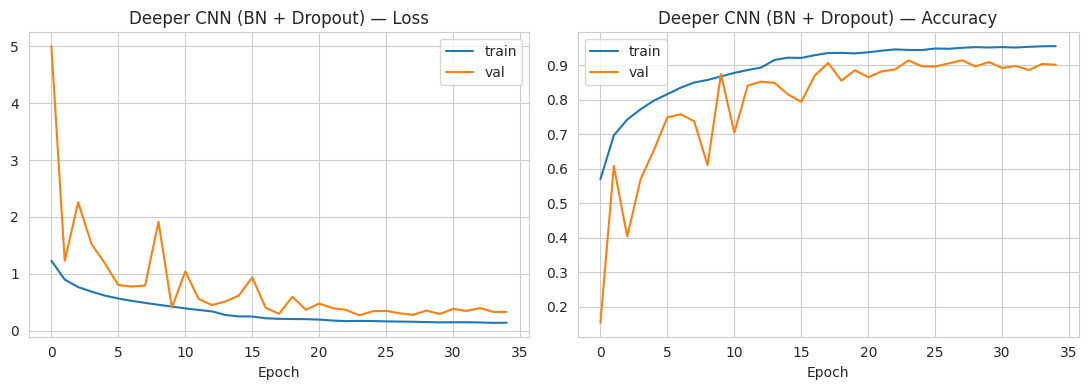


=== Deeper CNN ===
Test accuracy : 0.9175
Precision (w) : 0.9253
Recall    (w) : 0.9175
F1-score  (w) : 0.9182

Classification report:
                       precision    recall  f1-score   support

          AnnualCrop       0.98      0.88      0.92       450
              Forest       0.79      1.00      0.88       450
HerbaceousVegetation       0.90      0.88      0.89       450
             Highway       0.97      0.94      0.96       375
          Industrial       0.99      0.87      0.92       375
             Pasture       0.92      0.85      0.89       300
       PermanentCrop       0.91      0.89      0.90       375
         Residential       0.85      1.00      0.92       450
               River       0.97      0.94      0.96       375
             SeaLake       1.00      0.90      0.94       450

            accuracy                           0.92      4050
           macro avg       0.93      0.91      0.92      4050
        weighted avg       0.93      0.92      0.92    

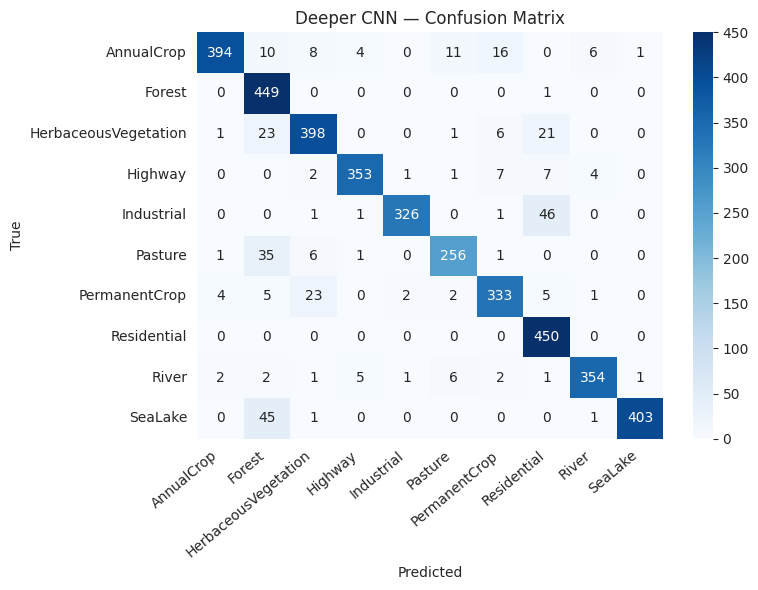

In [ ]:
plot_history(hist_deep, 'Deeper CNN (BN + Dropout)')
results.append(evaluate_model(deeper, 'Deeper CNN'))
with open(RESULTS_FILE, "a") as f:
    f.write("Deeper CNN\n")
    f.write(f"Training Time: {time_deep:.2f} seconds\n")
    f.write(f"Final Training Accuracy: {hist_deep.history['accuracy'][-1]:.4f}\n")
    f.write(f"Final Validation Accuracy: {hist_deep.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"Test Accuracy: {results[-1]['accuracy']:.4f}\n")
    f.write(f"Test Precision: {results[-1]['precision']:.4f}\n")
    f.write(f"Test Recall: {results[-1]['recall']:.4f}\n")
    f.write(f"Test F1 Score: {results[-1]['f1']:.4f}\n\n")

## 2.5.4 — Experimentation & Comparative Analysis

### 1) Baseline vs Deeper — performance & efficiency

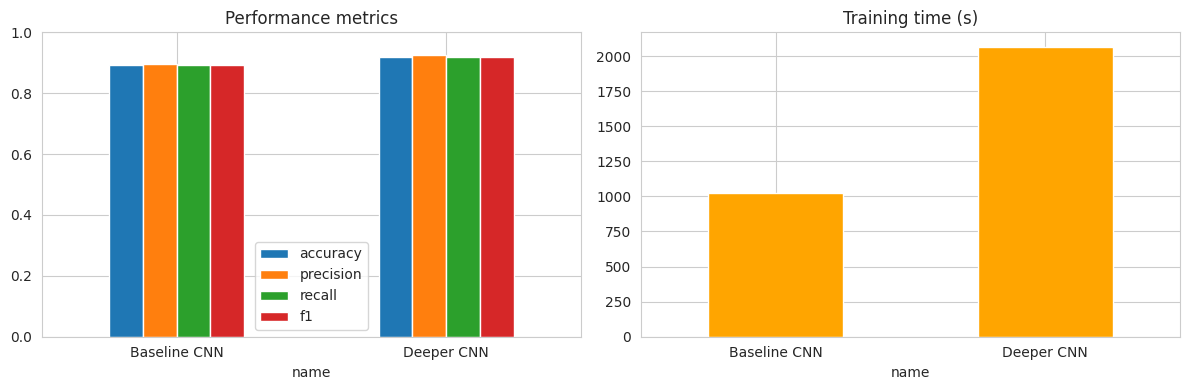

In [ ]:
comp_df = pd.DataFrame(results)
comp_df['training_time_s'] = [time_base, time_deep]
comp_df['params'] = [baseline.count_params(), deeper.count_params()]
comp_df

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
comp_df.set_index('name')[['accuracy','precision','recall','f1']].plot(kind='bar', ax=ax[0])
ax[0].set_title('Performance metrics'); ax[0].set_ylim(0, 1); ax[0].set_xticklabels(comp_df['name'], rotation=0)
comp_df.set_index('name')[['training_time_s']].plot(kind='bar', ax=ax[1], color='orange', legend=False)
ax[1].set_title('Training time (s)'); ax[1].set_xticklabels(comp_df['name'], rotation=0)
plt.tight_layout(); plt.show()

### 2) Optimizer comparison — SGD vs Adam (on the deeper architecture)

Epoch 1/10
296/296 - 77s - 260ms/step - accuracy: 0.4739 - loss: 1.4403 - val_accuracy: 0.1383 - val_loss: 4.1445
Epoch 2/10
296/296 - 45s - 152ms/step - accuracy: 0.6596 - loss: 0.9768 - val_accuracy: 0.4815 - val_loss: 1.6981
Epoch 3/10
296/296 - 47s - 160ms/step - accuracy: 0.7119 - loss: 0.8351 - val_accuracy: 0.6936 - val_loss: 0.9421
Epoch 4/10
296/296 - 46s - 155ms/step - accuracy: 0.7487 - loss: 0.7398 - val_accuracy: 0.5948 - val_loss: 1.3378
Epoch 5/10
296/296 - 81s - 274ms/step - accuracy: 0.7765 - loss: 0.6651 - val_accuracy: 0.7198 - val_loss: 0.8021
Epoch 6/10
296/296 - 82s - 276ms/step - accuracy: 0.7983 - loss: 0.6081 - val_accuracy: 0.6269 - val_loss: 1.5322
Epoch 7/10
296/296 - 89s - 300ms/step - accuracy: 0.8133 - loss: 0.5699 - val_accuracy: 0.6711 - val_loss: 1.0431
Epoch 8/10
296/296 - 44s - 149ms/step - accuracy: 0.8317 - loss: 0.5229 - val_accuracy: 0.5953 - val_loss: 1.3459
Epoch 9/10
296/296 - 45s - 152ms/step - accuracy: 0.8441 - loss: 0.4856 - val_accuracy: 

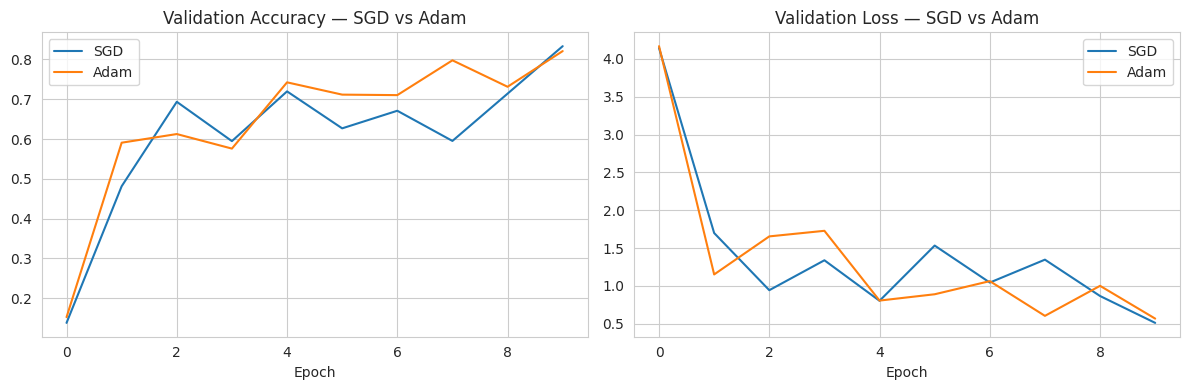

SGD  — final val acc: 0.8333, time: 602.3s
Adam — final val acc: 0.8210, time: 697.4s


In [ ]:
def fresh_deeper(opt):
    m = build_deeper()
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

EPOCHS_OPT = 10

# SGD with momentum
sgd_model = fresh_deeper(optimizers.SGD(learning_rate=1e-2, momentum=0.9))
t0 = time.time()
hist_sgd = sgd_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_OPT,
                         callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)], verbose=2)
time_sgd = time.time() - t0

# Adam (re-run for fairness, same epochs)
adam_model = fresh_deeper(optimizers.Adam(learning_rate=1e-3))
t0 = time.time()
hist_adam = adam_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_OPT,
                           callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)], verbose=2)
time_adam = time.time() - t0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_sgd.history['val_accuracy'], label='SGD')
ax[0].plot(hist_adam.history['val_accuracy'], label='Adam')
ax[0].set_title('Validation Accuracy — SGD vs Adam'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(hist_sgd.history['val_loss'], label='SGD')
ax[1].plot(hist_adam.history['val_loss'], label='Adam')
ax[1].set_title('Validation Loss — SGD vs Adam'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

print(f'SGD  — final val acc: {max(hist_sgd.history["val_accuracy"]):.4f}, time: {time_sgd:.1f}s')
print(f'Adam — final val acc: {max(hist_adam.history["val_accuracy"]):.4f}, time: {time_adam:.1f}s')
with open(RESULTS_FILE, "a") as f:
    f.write("Optimizer Comparison: SGD vs Adam\n")
    f.write(f"SGD Best Validation Accuracy: {max(hist_sgd.history['val_accuracy']):.4f}\n")
    f.write(f"SGD Training Time: {time_sgd:.2f} seconds\n")
    f.write(f"Adam Best Validation Accuracy: {max(hist_adam.history['val_accuracy']):.4f}\n")
    f.write(f"Adam Training Time: {time_adam:.2f} seconds\n\n")

### 3) Ablation study — remove BatchNorm, then remove Dropout

In [ ]:
import gc
import time
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import accuracy_score

RESULTS_FILE = "/content/drive/MyDrive/vision_training_results.txt"

ABLATION_TRAIN_LIMIT = 4000
ABLATION_VAL_LIMIT = 800
ABLATION_TEST_LIMIT = 800

X_tr_ab = X_tr[:ABLATION_TRAIN_LIMIT]
y_tr_ab = y_tr[:ABLATION_TRAIN_LIMIT]

X_val_ab = X_val[:ABLATION_VAL_LIMIT]
y_val_ab = y_val[:ABLATION_VAL_LIMIT]

X_te_ab = X_te[:ABLATION_TEST_LIMIT]
y_te_ab = y_te[:ABLATION_TEST_LIMIT]

INPUT_SHAPE = X_tr_ab.shape[1:]
NUM_CLASSES = len(np.unique(y_tr))

def make_deeper(use_batchnorm=True, use_dropout=True):
    model = keras.Sequential(name="deeper_ablation_fast")

    model.add(layers.Input(shape=INPUT_SHAPE))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation="relu"))
    if use_dropout:
        model.add(layers.Dropout(0.4))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def train_ablation_fast(model_fn, name):
    gc.collect()
    tf.keras.backend.clear_session()

    model = model_fn()

    t0 = time.time()

    hist = model.fit(
        X_tr_ab,
        y_tr_ab,
        validation_data=(X_val_ab, y_val_ab),
        epochs=20,
        batch_size=32,
        callbacks=[
            callbacks.EarlyStopping(
                patience=1,
                restore_best_weights=True
            )
        ],
        verbose=2
    )

    train_time = time.time() - t0

    y_pred = np.argmax(model.predict(X_te_ab, batch_size=32, verbose=1), axis=1)
    test_acc = accuracy_score(y_te_ab, y_pred)
    best_val_acc = max(hist.history["val_accuracy"])

    print(f"{name:15s} | best val acc: {best_val_acc:.4f} | test acc: {test_acc:.4f} | time: {train_time:.1f}s")

    return {
        "variant": name,
        "val_acc": best_val_acc,
        "test_acc": test_acc,
        "time_seconds": train_time
    }

ablation_results = []

ablation_results.append(
    train_ablation_fast(
        lambda: make_deeper(use_batchnorm=False, use_dropout=True),
        "No BatchNorm"
    )
)

ablation_results.append(
    train_ablation_fast(
        lambda: make_deeper(use_batchnorm=True, use_dropout=False),
        "No Dropout"
    )
)

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

with open(RESULTS_FILE, "a") as f:
    f.write("Ablation Study\n")
    for _, row in ablation_df.iterrows():
        f.write(f"{row['variant']}\n")
        f.write(f"Best Validation Accuracy: {row['val_acc']:.4f}\n")
        f.write(f"Test Accuracy: {row['test_acc']:.4f}\n")
        f.write(f"Training Time: {row['time_seconds']:.2f} seconds\n")
    f.write("\n")

print("Ablation results appended to:", RESULTS_FILE)

Epoch 1/20
125/125 - 11s - 85ms/step - accuracy: 0.2480 - loss: 2.2378 - val_accuracy: 0.3675 - val_loss: 1.5546
Epoch 2/20
125/125 - 1s - 12ms/step - accuracy: 0.3927 - loss: 1.5688 - val_accuracy: 0.5838 - val_loss: 1.4016
Epoch 3/20
125/125 - 3s - 21ms/step - accuracy: 0.4780 - loss: 1.3810 - val_accuracy: 0.6313 - val_loss: 1.1050
Epoch 4/20
125/125 - 1s - 11ms/step - accuracy: 0.5403 - loss: 1.2599 - val_accuracy: 0.5950 - val_loss: 1.0830
Epoch 5/20
125/125 - 1s - 11ms/step - accuracy: 0.5863 - loss: 1.1705 - val_accuracy: 0.5688 - val_loss: 1.1843
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
No BatchNorm    | best val acc: 0.6313 | test acc: 0.5988 | time: 18.3s
Epoch 1/20
125/125 - 8s - 67ms/step - accuracy: 0.5965 - loss: 1.1505 - val_accuracy: 0.3200 - val_loss: 1.7237
Epoch 2/20
125/125 - 2s - 13ms/step - accuracy: 0.7325 - loss: 0.7556 - val_accuracy: 0.3300 - val_loss: 2.5141
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
No Dropout      | best val acc: 0.3300 | test acc: 0.3400 | time:

,variant,val_acc,test_acc,time_seconds
0,No BatchNorm,0.63125,0.59875,18.292141
1,No Dropout,0.33000,0.34000,10.533566


Ablation results appended to: /content/drive/MyDrive/vision_training_results.txt


In [ ]:
total_time = time_base + time_deep + time_sgd + time_adam
print(f'Total training time across all from-scratch experiments: {total_time:.1f} s ({total_time/60:.1f} min)')

## Part B — Transfer Learning


In [ ]:
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks, optimizers
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

RESULTS_FILE = "/content/drive/MyDrive/vision_training_results.txt"

IMG_SIZE_TL = (160, 160)
BATCH_TL = 16

TL_TRAIN_LIMIT = 6000
TL_VAL_LIMIT = 1200
TL_TEST_LIMIT = 1200

X_tr_tl = X_tr[:TL_TRAIN_LIMIT]
y_tr_tl = y_tr[:TL_TRAIN_LIMIT]

X_val_tl = X_val[:TL_VAL_LIMIT]
y_val_tl = y_val[:TL_VAL_LIMIT]

X_te_tl = X_te[:TL_TEST_LIMIT]
y_te_tl = y_te[:TL_TEST_LIMIT]

def to_tl_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype("float32"), y))

    ds = ds.map(
        lambda x, y: (tf.image.resize(x, IMG_SIZE_TL), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.map(
        lambda x, y: (applications.mobilenet_v2.preprocess_input(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(1024, seed=SEED)

    return ds.batch(BATCH_TL).prefetch(1)

tl_train = to_tl_ds(X_tr_tl, y_tr_tl, training=True)
tl_val = to_tl_ds(X_val_tl, y_val_tl)
tl_test = to_tl_ds(X_te_tl, y_te_tl)

print("Transfer learning datasets ready")
print("Train:", len(X_tr_tl))
print("Validation:", len(X_val_tl))
print("Test:", len(X_te_tl))

Transfer learning datasets ready
Train: 6000
Validation: 1200
Test: 1200


In [ ]:
tf.keras.backend.clear_session()
gc.collect()

NUM_CLASSES = len(np.unique(y_tr))

base = applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(160, 160, 3)
)

base.trainable = False

inputs = keras.Input(shape=(160, 160, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

tl_model = keras.Model(inputs, outputs, name="MobileNetV2_Transfer_Learning")

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
t0 = time.time()

hist_tl1 = tl_model.fit(
    tl_train,
    validation_data=tl_val,
    epochs=5,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True
        )
    ],
    verbose=2
)

time_tl1 = time.time() - t0

print(f"Stage 1 frozen-base training time: {time_tl1:.2f} seconds")

Epoch 1/5
375/375 - 8s - 21ms/step - accuracy: 0.9158 - loss: 0.2506 - val_accuracy: 0.9308 - val_loss: 0.1993
Epoch 2/5
375/375 - 7s - 18ms/step - accuracy: 0.9240 - loss: 0.2290 - val_accuracy: 0.9133 - val_loss: 0.2428
Stage 1 frozen-base training time: 14.88 seconds


In [ ]:
base.trainable = True

for layer in base.layers[:-20]:
    layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

t0 = time.time()

hist_tl2 = tl_model.fit(
    tl_train,
    validation_data=tl_val,
    epochs=5,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True
        )
    ],
    verbose=2
)

time_tl2 = time.time() - t0

print(f"Stage 2 fine-tuning time: {time_tl2:.2f} seconds")

Epoch 1/5
375/375 - 34s - 89ms/step - accuracy: 0.8910 - loss: 0.3263 - val_accuracy: 0.9375 - val_loss: 0.1953
Epoch 2/5
375/375 - 7s - 20ms/step - accuracy: 0.9028 - loss: 0.2839 - val_accuracy: 0.9367 - val_loss: 0.1879
Epoch 3/5
375/375 - 6s - 17ms/step - accuracy: 0.9155 - loss: 0.2481 - val_accuracy: 0.9367 - val_loss: 0.1863
Epoch 4/5
375/375 - 7s - 20ms/step - accuracy: 0.9238 - loss: 0.2297 - val_accuracy: 0.9367 - val_loss: 0.1857
Epoch 5/5
375/375 - 7s - 19ms/step - accuracy: 0.9288 - loss: 0.2063 - val_accuracy: 0.9400 - val_loss: 0.1758
Stage 2 fine-tuning time: 64.98 seconds


In [ ]:
def merge_histories(h1, h2):
    merged = {}

    for key in h1.history.keys():
        merged[key] = h1.history[key] + h2.history[key]

    return type("MergedHistory", (), {"history": merged})()

hist_tl = merge_histories(hist_tl1, hist_tl2)

try:
    plot_history(hist_tl, "MobileNetV2 Transfer Learning with Fine-tuning")
except NameError:
    print("plot_history function not found, skipping history plot.")

y_pred_tl = np.argmax(tl_model.predict(tl_test, verbose=0), axis=1)

acc = accuracy_score(y_te_tl, y_pred_tl)

p, r, f1, _ = precision_recall_fscore_support(
    y_te_tl,
    y_pred_tl,
    average="weighted",
    zero_division=0
)

print(f"\nMobileNetV2 Transfer Learning with Fine-tuning")
print(f"Test accuracy : {acc:.4f}")
print(f"Precision (w) : {p:.4f}")
print(f"Recall    (w) : {r:.4f}")
print(f"F1-score  (w) : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_te_tl, y_pred_tl, target_names=CLASS_NAMES, zero_division=0))

with open(RESULTS_FILE, "a") as file:
    file.write("MobileNetV2 Transfer Learning with Fine-tuning\n")
    file.write(f"Stage 1 Training Time: {time_tl1:.2f} seconds\n")
    file.write(f"Stage 2 Fine-tuning Time: {time_tl2:.2f} seconds\n")
    file.write(f"Final Training Accuracy: {hist_tl.history['accuracy'][-1]:.4f}\n")
    file.write(f"Final Training Loss: {hist_tl.history['loss'][-1]:.4f}\n")
    file.write(f"Final Validation Accuracy: {hist_tl.history['val_accuracy'][-1]:.4f}\n")
    file.write(f"Final Validation Loss: {hist_tl.history['val_loss'][-1]:.4f}\n")
    file.write(f"Test Accuracy: {acc:.4f}\n")
    file.write(f"Test Precision (weighted): {p:.4f}\n")
    file.write(f"Test Recall (weighted): {r:.4f}\n")
    file.write(f"Test F1 Score (weighted): {f1:.4f}\n\n")

print("Transfer learning results appended to:", RESULTS_FILE)

plot_history function not found, skipping history plot.

MobileNetV2 Transfer Learning with Fine-tuning
Test accuracy : 0.9350
Precision (w) : 0.9357
Recall    (w) : 0.9350
F1-score  (w) : 0.9350

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.93      0.93       147
              Forest       0.97      0.93      0.95       120
HerbaceousVegetation       0.86      0.90      0.88       125
             Highway       0.88      0.85      0.86       105
          Industrial       0.99      0.98      0.99       123
             Pasture       0.92      0.94      0.93        84
       PermanentCrop       0.92      0.86      0.89        99
         Residential       0.97      1.00      0.99       148
               River       0.89      0.94      0.91       108
             SeaLake       0.99      0.97      0.98       141

            accuracy                           0.94      1200
           macro avg       0.93   

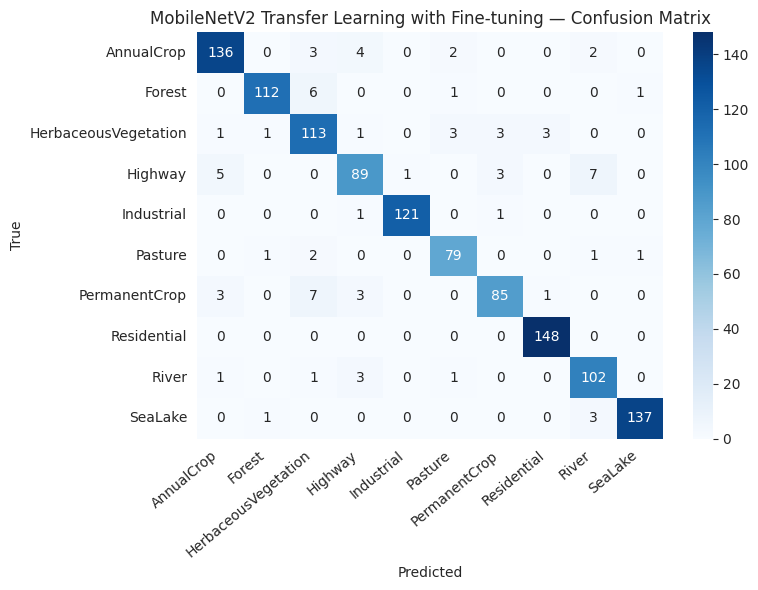

In [ ]:
cm = confusion_matrix(y_te_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MobileNetV2 Transfer Learning with Fine-tuning — Confusion Matrix")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

## Final Comparison — All Models

,name,accuracy,precision,recall,f1
0,Baseline CNN,0.8926,0.8958,0.8926,0.8924
1,Deeper CNN,0.9175,0.9253,0.9175,0.9182
2,MobileNetV2 (TL),0.9350,0.9357,0.9350,0.9350


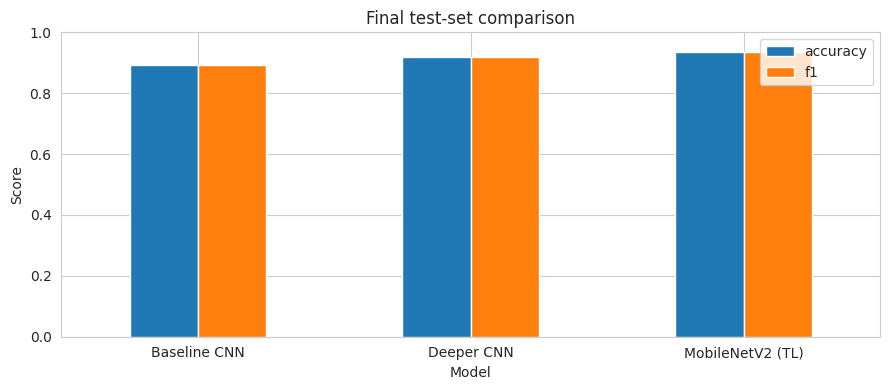

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

final_results = [
    {
        "name": "Baseline CNN",
        "accuracy": 0.8926,
        "precision": 0.8958,
        "recall": 0.8926,
        "f1": 0.8924
    },
    {
        "name": "Deeper CNN",
        "accuracy": 0.9175,
        "precision": 0.9253,
        "recall": 0.9175,
        "f1": 0.9182
    }
]

if "acc" in globals() and "p" in globals() and "r" in globals() and "f1" in globals():
    final_results.append({
        "name": "MobileNetV2 (TL)",
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1
    })

final_df = pd.DataFrame(final_results)

display(final_df.round(4))

ax = final_df.set_index("name")[["accuracy", "f1"]].plot(
    kind="bar",
    figsize=(9, 4)
)

ax.set_ylim(0, 1)
ax.set_title("Final test-set comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_xticklabels(final_df["name"], rotation=0)

plt.tight_layout()
plt.show()